# Default NV model builders

The basic tutorial constructs a model that represents a nitrogen-vacancy (NV) center by hand. This tutorial uses the **built-in NV models** to construct the same kind of model.


The workflow is:

1. Start with the NV electron only.
2. Tilt the static magnetic field and compare quantization-axis choices.
3. Add the nitrogen nuclear spin.
4. Add selected carbon-13 spins from the hyperfine database.
5. Build two-NV models.
6. Compare same-orientation and different-orientation multi-NV models.

In [1]:
import numpy as np
import simphony

simphony.Config.set_matplotlib_format('retina')

## Default single NV model

<span style="font-variant: small-caps;">Simphony</span> provides a built-in function to construct a default NV center model. Using the `default_nv_model()` function, you can **define a model containing a single NV electron spin**. When the levels are plotted, the spectrum shows the spin-1 electron levels in a relatively strong magnetic field:

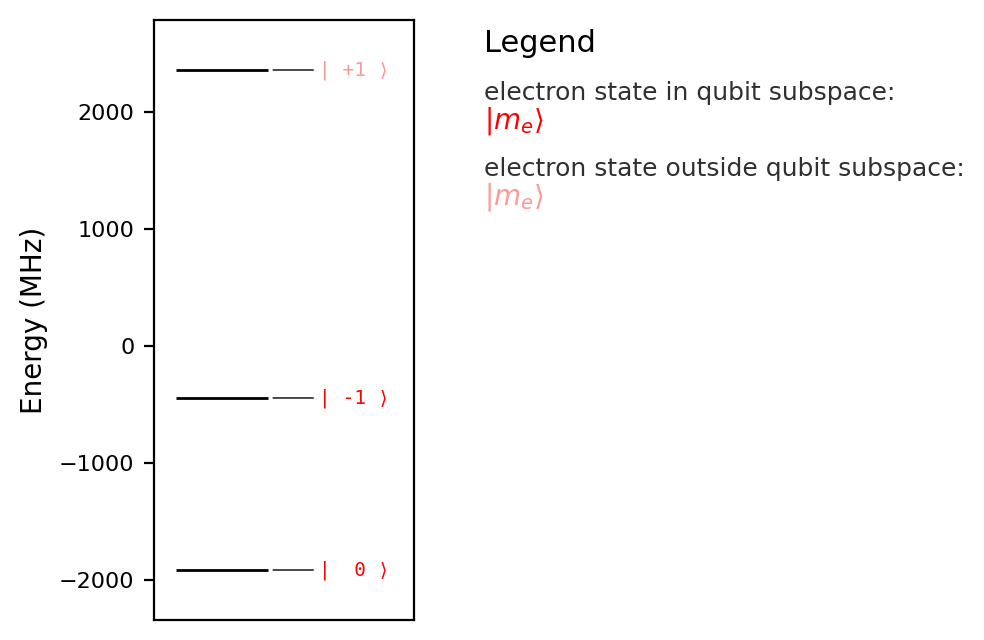

In [2]:
model = simphony.default_nv_model(nitrogen_isotope=None,
                                  static_field_strength=0.05)

model.plot_levels()

A single electron **spin is attached to the model** with the proper zero field splitting:

In [3]:
model.spins

[ElectronSpin(dimension=3, name='e', qubit_subspace=(0, -1), zero_field_splitting=2872.0)]

The **crystallographic axis** (we refer to this as **anisotropy axis** here) is hard-coded in the `default_nv_model` to point along the global **z-axis**:

In [4]:
model.spin('e').anisotropy_axis.vec

(0.0, 0.0, 1.0)

The **default static field** points along the **z-axis** too:

In [5]:
model.static_fields

[StaticField(strengths=(0.0, 0.0, 0.05))]

The builder also creates the **standard MW and RF linearly polarized driving fields** that point along the **x-axis**:

In [6]:
model.driving_fields

[LinearDrivingField(name='MW_x', direction=(1.0, 0.0, 0.0)),
 LinearDrivingField(name='RF_x', direction=(1.0, 0.0, 0.0))]

## Tilted static magnetic field

With `static_field_direction`, you can **tilt the direction of the static field**, for example, by aligning with the x-axis:

/data/bope/codex_sandbox/simphony/simphony/model.py:1382: SimphonyWarning: Eigenstates are labelled via a one-to-one maximal-overlap assignment to local-S_z product-basis states. 3 assigned labels have overlap below 0.9:
eigenstate: - product state -> overlap
--------------------------------------
( 1.0): - ( 0.0) -> 0.376
        - ( 1.0) -> 0.312
        - (-1.0) -> 0.312
(-1.0): - (-1.0) -> 0.500
        - ( 1.0) -> 0.500
( 0.0): - ( 0.0) -> 0.624
        - (-1.0) -> 0.188
        - ( 1.0) -> 0.188
  warn(


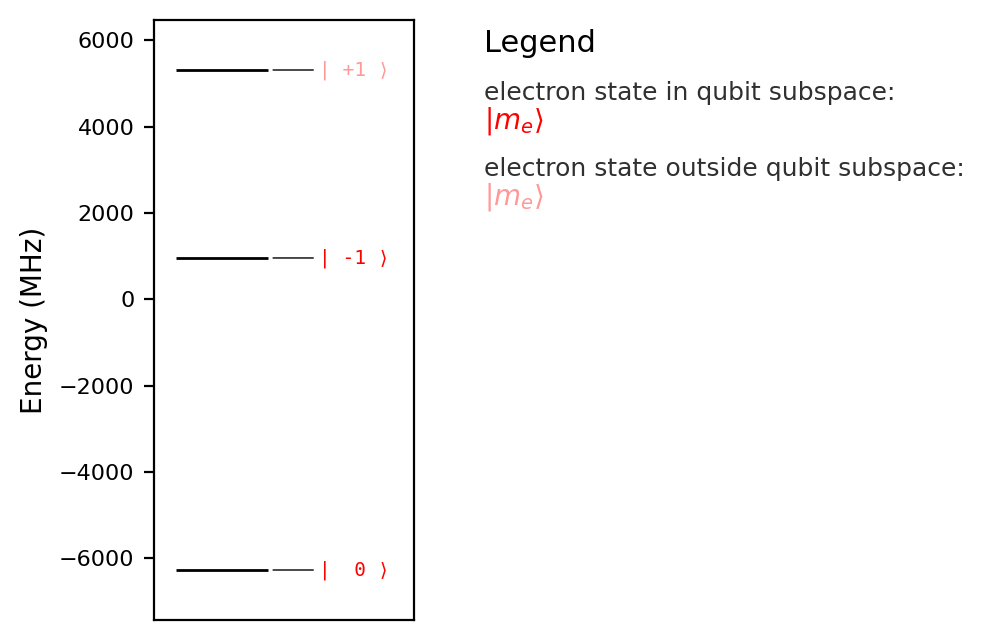

In [7]:
model = simphony.default_nv_model(nitrogen_isotope=None,
                                  static_field_strength=0.2,
                                  static_field_direction=[1,0,0])

model.plot_levels()

A labeling warning is expected here because the chosen basis does not align well with the eigenstates. In <span style="font-variant: small-caps;">Simphony</span>, **eigenstate labeling is based on the overlap with the local-$S_z$ eigenstates, or local-$S_z$ product-basis states in the case of multiple spins**, defined by the chosen quantization axis, using a one-to-one maximal-overlap assignment.

You can change the **`quantization_axis` convention by choosing** `'global_z'`, `'local_static_field'`, `'anisotropy_axis'` or a **general unit vector**. In the current model, because the strong Zeeman term dominates the zero-field splitting term, we select `'local_static_field'`:

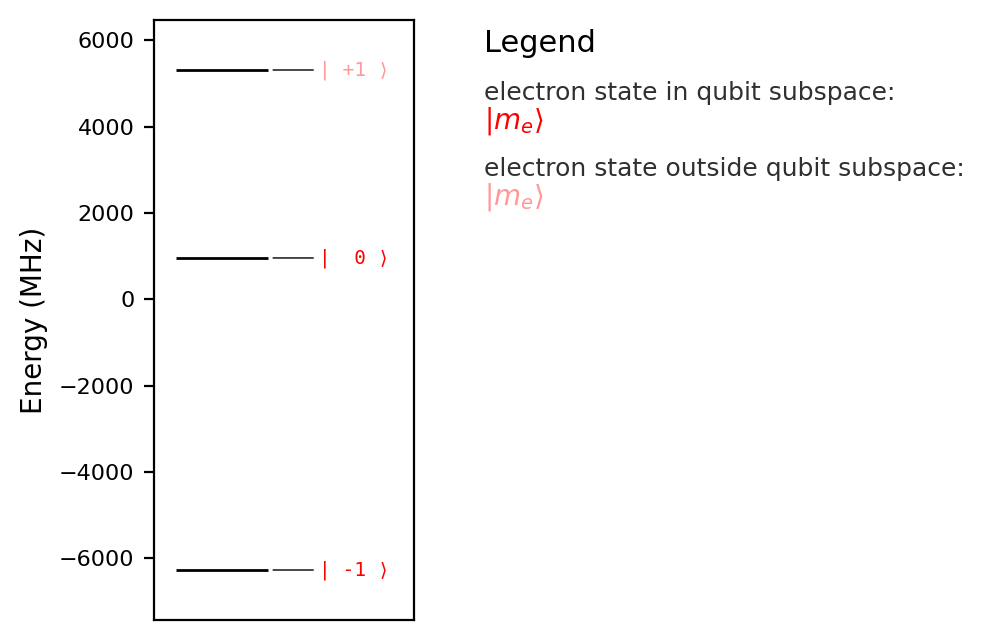

In [8]:
model = simphony.default_nv_model(nitrogen_isotope=None,
                                  static_field_strength=0.2,
                                  static_field_direction=[1,0,0],
                                  quantization_axis='local_static_field')

model.plot_levels()

Overlaps between the eigenstates and local-$S_z$ product-basis states can be checked by the model's `test_labeling()` method:

In [9]:
model.test_labeling(output='print')

eigenstate: - product state -> overlap
--------------------------------------
(-1.0): - (-1.0) -> 0.984
        - ( 1.0) -> 0.016
( 1.0): - ( 1.0) -> 0.984
        - (-1.0) -> 0.016
( 0.0): - ( 0.0) -> 1.000


Now the eigenstate labels are dominated by a single local-$S_z$ product-basis state. This is the diagnostic to use when a field or orientation choice makes the spectrum harder to label. 

## Add nitrogen and nearby carbon spins to the default model

A **nitrogen nuclear spin** can be added by specifying its **isotope number** through the `nitrogen_isotope` argument, which must be `14`, `15`, or `None`.

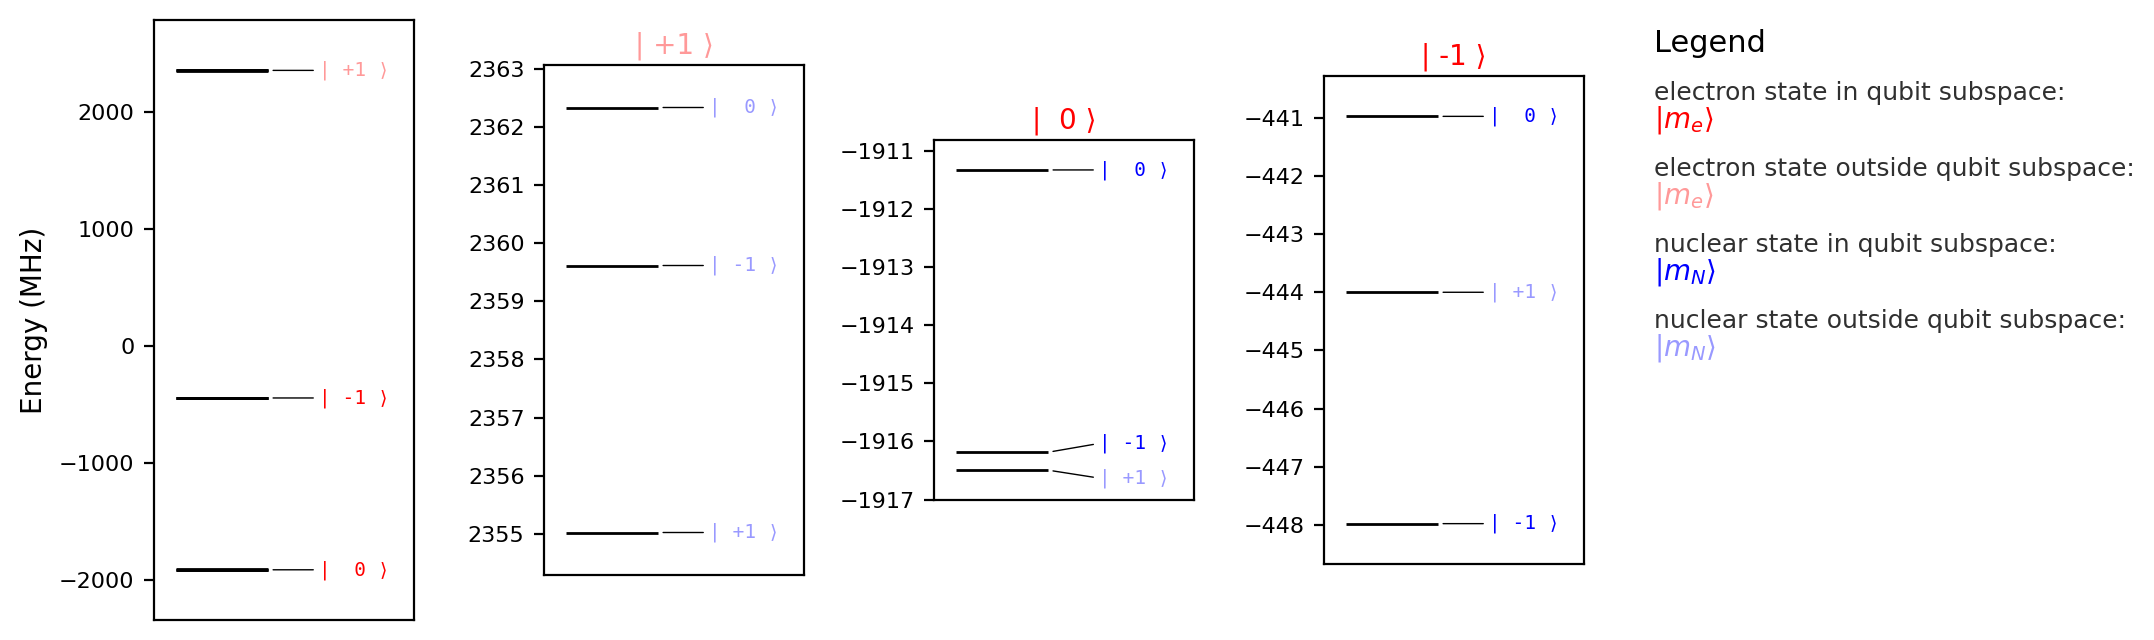

In [10]:
model = simphony.default_nv_model(nitrogen_isotope=14,
                                  static_field_strength=0.05)

model.plot_levels()

Additional **carbon-13 nuclear spins** can be included using the `carbon_atom_indices` argument to choose nuclear-spin sites and **determine the hyperfine tensors**, based on the [Ivády Group’s hyperfine dataset](https://ivadygroup.elte.hu/hyperfine/nv/index.html). As mentioned above, the NV axis is aligned with the global z-direction.

The `carbon_atom_indices` must be a **list of tuples**. Each tuple $(n_1, n_2, n_3, n_4)$ defines the position of a carbon atom as:

$$
\text{carbon atom position} = n_1 \cdot \mathbf{a}_1 + n_2 \cdot \mathbf{a}_2 + n_3 \cdot \mathbf{a}_3 + n_4 \cdot \boldsymbol{\tau},
$$

where $\mathbf{a}_1$, $\mathbf{a}_2$, and $\mathbf{a}_3$ are the primitive lattice vectors, and $\mathbf{0}$ and $\boldsymbol{\tau}$ are the positions of the carbon atoms inside the primitive cell. The indices $n_1$, $n_2$, $n_3$ are integers, and $n_4$ is either $0$ or $1$. Our convention is:

$$
\begin{aligned}
\mathbf{a}_1 &= a_\text{CC}\cdot \left( 0, \frac{2\sqrt{2}}{3}, \frac{4}{3} \right), \\
\mathbf{a}_2 &= a_\text{CC}\cdot \left( -\frac{\sqrt{6}}{3}, -\frac{\sqrt{2}}{3}, \frac{4}{3} \right), \\
\mathbf{a}_3 &= a_\text{CC}\cdot \left( \frac{\sqrt{6}}{3}, -\frac{\sqrt{2}}{3}, \frac{4}{3} \right), \\
\boldsymbol{\tau} &= \frac{\mathbf{a}_1 + \mathbf{a}_2 + \mathbf{a}_3}{4} = a_\text{CC}\cdot (0, 0, 1),
\end{aligned}
$$

where $a_\text{CC} = 0.1545\ \text{nm}$ is the carbon–carbon distance. The nitrogen occupies the $\boldsymbol{\tau}$ position, while the missing carbon atom (vacancy) corresponds to the $\mathbf{0}$ lattice point.

The spin-Hamiltonian describes the default NV model:

$$
H =
\underbrace{\gamma_{e} \mathbf{B} \cdot \mathbf{S} + D S_z^2}_{\text{electron}}
+
\underbrace{-\gamma_{N} \mathbf{B} \cdot \mathbf{I}_{N} + P I_{N,z}^2 + \mathbf{S} \cdot \mathbf{A}_{N} \cdot \mathbf{I}_{N}}_{\text{nitrogen}}
+
\underbrace{\sum_{i} \left(-\gamma_{C} \mathbf{B} \cdot \mathbf{I}_{C}^{(i)} + \mathbf{S} \cdot \mathbf{A}_{C}^{(i)} \cdot \mathbf{I}_{C}^{(i)} \right)}_{\text{carbon(s)}}.
$$

| Spin                        | Parameter               | Symbol                 | Value                               |
|------------------------------|------------------------|-----------------------|-------------------------------------|
| Electron $(S=1)$               | Gyromagnetic ratio      | $γ_e$                   | 28.0331 GHz/T [1]                   |
|                              | Zero-field splitting    | $D$                     | 2.872 GHz [1]                        |
| Nitrogen-14 $(I=1)$            | Gyromagnetic ratio      | $γ_N$                   | 3.07771 MHz/T [2]                  |
|                              | Quadrupole splitting    | $P$                     | -5.01 MHz [1]                        |
|                              | Hyperfine perpendicular | $A_{N\perp}$                  | -2.70 MHz [1]                        |
|                              | Hyperfine parallel      | $A_{N\parallel}$                  | -2.14 MHz [1]                        |
| Nitrogen-15 $(I=1/2)$          | Gyromagnetic ratio      | $γ_N$                   | -4.31727 MHz/T [2]                   |
|                              | Hyperfine perpendicular | $A_{N\perp}$                  | 3.65 MHz [1]                         |
|                              | Hyperfine parallel      | $A_{N\parallel}$                  | 3.03 MHz [1]                         |
| Carbon-13 $(I=1/2)$            | Gyromagnetic ratio      | $γ_C$                   | 10.7084 MHz/T [2]                  |

**References:**

[1] Felton et al., Phys. Rev. B 79, 075203 (2009)  
[2] CRC Handbook of Chemistry and Physics, sec. 11-4 (97th edition)


A simple spin system consisting of **an NV electron spin**, a **$^{14}\text{N}$ nuclear spin**, and **two $^{13}\text{C}$ nuclear spins** can be defined as:

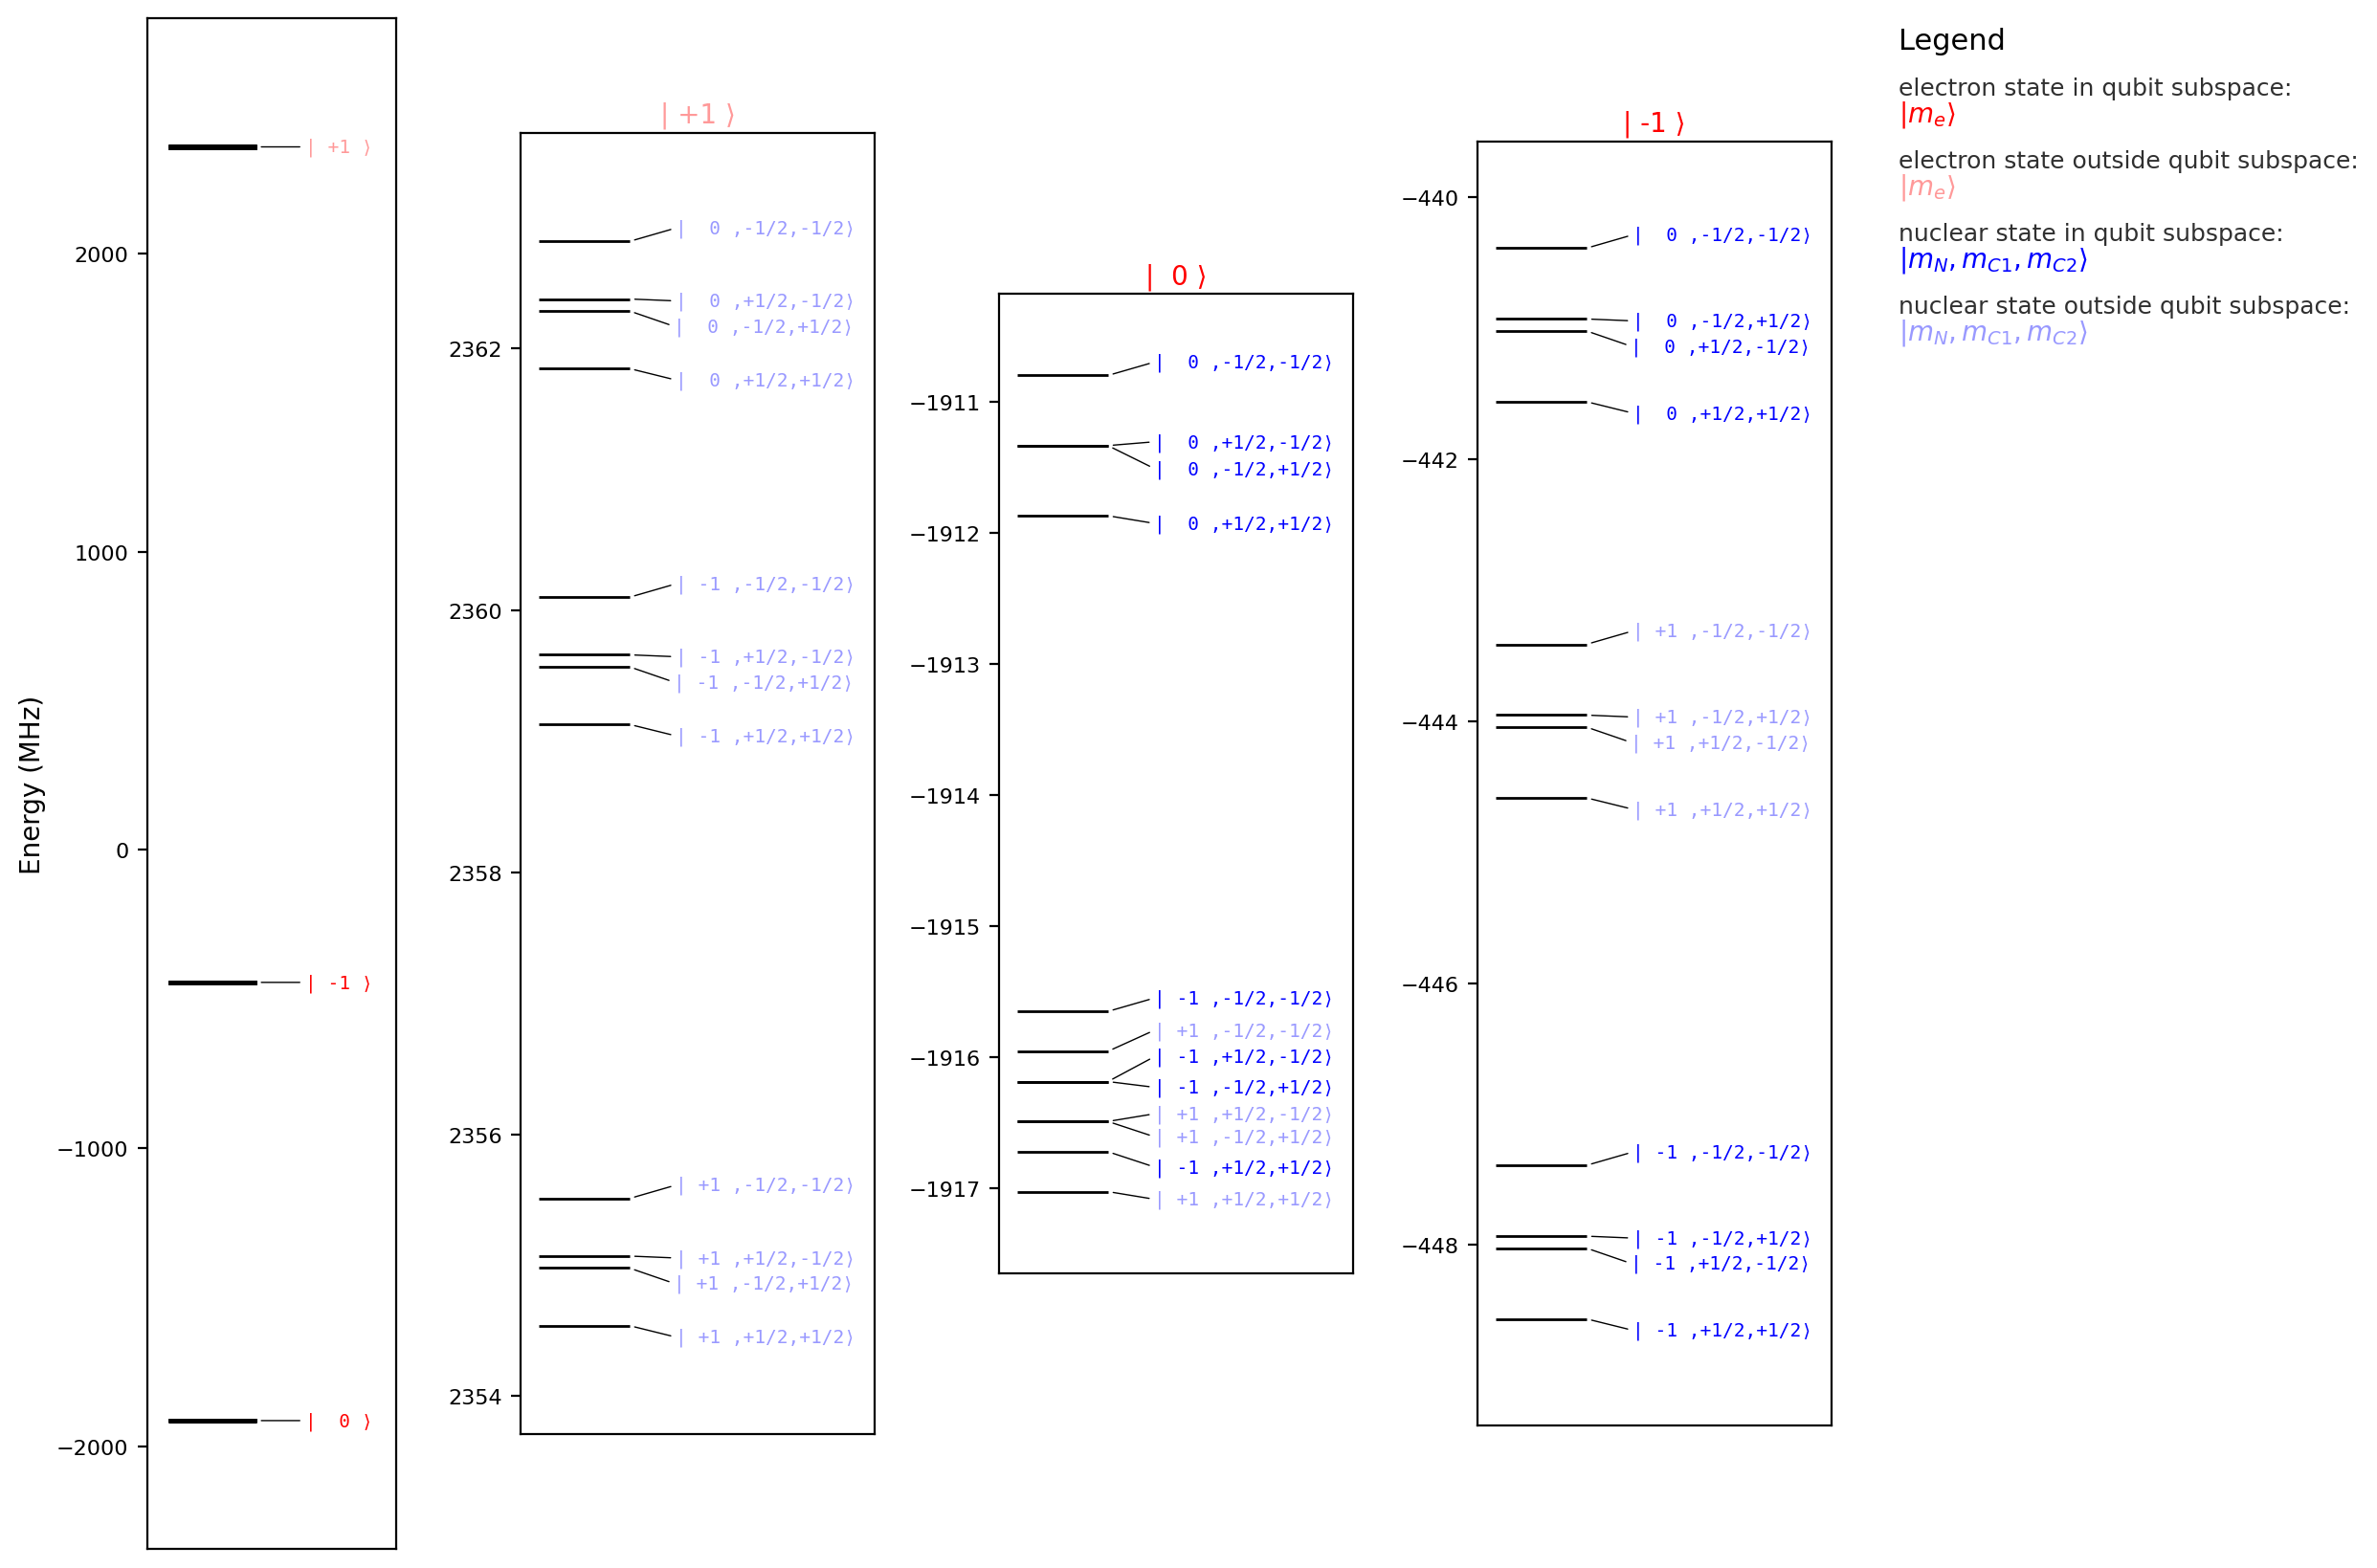

In [11]:
model = simphony.default_nv_model(nitrogen_isotope=14,
                                  carbon_atom_indices=[(1,1,1,0),(2,-3,4,1)],
                                  static_field_strength=0.05)

model.plot_levels()

The resulting model contains four **attached spins** and **three spin-spin interactions**, as expected for this electron-nitrogen-two-carbon system:

In [12]:
model.spins

[ElectronSpin(dimension=3, name='e', qubit_subspace=(0, -1), zero_field_splitting=2872.0),
 NuclearSpin(dimension=3, name='N', qubit_subspace=(0, -1), quadrupole_splitting=-5.01),
 NuclearSpin(dimension=2, name='C1', qubit_subspace=(-0.5, 0.5)),
 NuclearSpin(dimension=2, name='C2', qubit_subspace=(-0.5, 0.5))]

In [13]:
model.interactions

[Interaction(spin_name_1='e', spin_name_2='N', diag=[-2.7, -2.7, -2.14], offdiag='zero'),
 Interaction(spin_name_1='e', spin_name_2='C1', diag=[-0.06727, -0.06727, 0.095884], offdiag='approx_zero'),
 Interaction(spin_name_1='e', spin_name_2='C2', diag=[0.005059, -0.009612, 0.004552], offdiag='nonzero')]

By default, each default NV model includes a `RotatingFrameSetter`, which **recomputes the rotating-frame frequency** of each spin from its current qubit splitting whenever the model parameters change. The default configuration uses `rest_electron_spin_state='1'` and `rest_nuclear_spin_state='avg'`: when the rotating-frame frequency of one spin is computed, <span style="font-variant: small-caps;">Simphony</span> calculates that spin’s qubit splitting while fixing the other electron spins to qubit state `'1'` and averaging over the other nuclear spins:

In [14]:
model.rotating_frame

RotatingFrameSetter(rest_electron_spin_state='1', rest_nuclear_spin_state='avg')

The default **qubit subspaces** corresponding the spins are:

In [15]:
{spin.name: spin.qubit_subspace for spin in model.spins}

{'e': (0, -1), 'N': (0, -1), 'C1': (-0.5, 0.5), 'C2': (-0.5, 0.5)}

That can be changed easily at initialization by the `qubit_subspace_electron`, `qubit_subspace_nitrogen` and `qubit_subspace_carbon` arguments. The qubit subspace defines which two local spin states are treated as the computational states of each spin, so setting it explicitly makes later gate simulations and pulse-design examples unambiguous.

## Hyperfine database

The hyperfine database can be accessed directly by:

In [16]:
db = simphony.default_nv_hyperfine_database()
len(db)

19924

The **database** contains information regarding **site indices**, **positions** (both ideal and DFT), occupied **atoms**, and $^{13}\text{C}$ **hyperfine interactions**:

In [17]:
db[:3]

(NVLatticeSite(
   type='N',
   index=(0, 0, 0, 1),
   hyperfine=nan,
   lattice_positions=(1.11022e-16, -2.498e-16, 0.772278),
   dft_positions=(4.35002e-06, 2.60769e-06, 0.93198),
   distance_from_lattice_center=0.772278,
 ),
 NVLatticeSite(
   type='V',
   index=(0, 0, 0, 0),
   hyperfine=nan,
   lattice_positions=(0, 0, -0.772278),
   dft_positions=(0, -4.44089e-16, -0.772278),
   distance_from_lattice_center=0.772278,
 ),
 NVLatticeSite(
   type='C',
   index=(-1, 0, 0, 1),
   hyperfine=(
     (109.921, -0.000324996, -0.000111407),
     (-0.000324996, 187.35, 25.4812),
     (-0.000111407, 25.4812, 117.999),
   ),
   lattice_positions=(-1.05407e-17, -1.45622, -1.28713),
   dft_positions=(5.59251e-06, -1.53528, -1.34177),
   distance_from_lattice_center=1.94352,
 ))

## Build coupled NV-center models

Function `default_multi_nv_model()` extends the builder to several NV centers. In this example, **dipole-dipole coupled NV centers** are created with the same **crystallographic orientation** and without nuclear spins. The orientation should be one of `(1, 1, 1)`, `(1, -1, -1)`, `(-1, 1, -1)`, or `(-1, -1, 1)`, representing the possible crystallographic axes of NV centers in diamond. The **positions of the NV centers** are passed through the `positions` argument, given in $\text{nm}$:

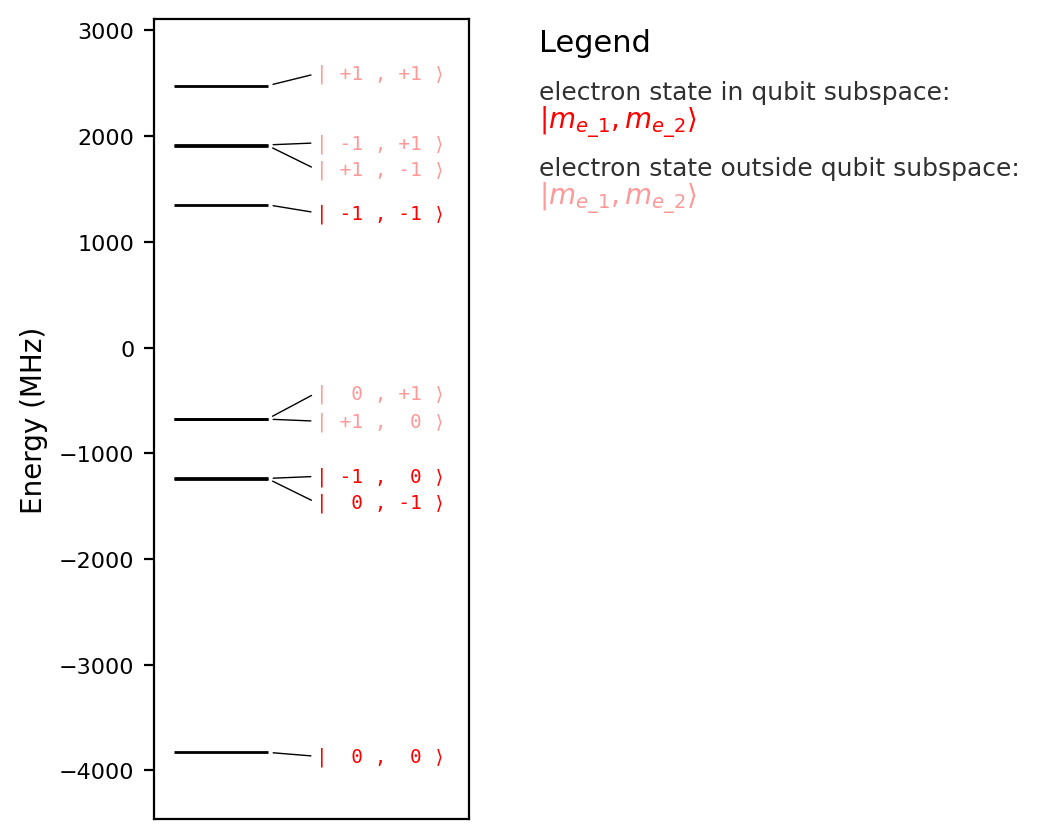

['e_1', 'e_2']

In [18]:
model = simphony.default_multi_nv_model(orientations=[(1,1,1),(1,1,1)],
                                        positions=[[0,0,0],[1,3,10]],
                                        nitrogen_isotopes=None,
                                        static_field_strengths=[0.01,0.0101])

model.plot_levels()
model.spin_names

Passing a list to `static_field_strengths` creates separate static fields for the spins:

In [19]:
model.static_fields

[StaticField(strengths=(0.0, 0.0, 0.01), target_spins=('e_1',)),
 StaticField(strengths=(0.0, 0.0, 0.0101), target_spins=('e_2',))]

The previous model used two different field strengths, so the builder created targeted static fields rather than one global field. The target list tells which spins each field acts on. This matters later when a model contains electron and nuclear spins from several centers: a **field or drive can be global, or it can be restricted to one part of the register**. A scalar `static_field_strengths` value creates one global field; a list creates targeted fields for the corresponding centers.

## Two NV centers with different orientations

Now the second NV center is placed along a **different crystallographic orientation**. With the default quantization convention, both electron spins are still represented in the global-z basis even though their anisotropy axes differ, which leads to problematic labeling:

/data/bope/codex_sandbox/simphony/simphony/model.py:1382: SimphonyWarning: Eigenstates are labelled via a one-to-one maximal-overlap assignment to local-S_z product-basis states. 9 assigned labels have overlap below 0.9:
eigenstate: - product state -> overlap
--------------------------------------
( 1.0,  0.0): - ( 1.0,  0.0) -> 0.531
              - ( 1.0, -1.0) -> 0.360
              - ( 1.0,  1.0) -> 0.108
( 1.0,  1.0): - ( 1.0,  1.0) -> 0.531
              - ( 1.0,  0.0) -> 0.360
              - ( 1.0, -1.0) -> 0.108
( 1.0, -1.0): - ( 1.0, -1.0) -> 0.531
              - ( 1.0,  1.0) -> 0.360
              - ( 1.0,  0.0) -> 0.108
( 0.0,  1.0): - ( 0.0,  1.0) -> 0.531
              - ( 0.0,  0.0) -> 0.360
              - ( 0.0, -1.0) -> 0.108
( 0.0, -1.0): - ( 0.0, -1.0) -> 0.531
              - ( 0.0,  1.0) -> 0.360
              - ( 0.0,  0.0) -> 0.108
( 0.0,  0.0): - ( 0.0,  0.0) -> 0.531
              - ( 0.0, -1.0) -> 0.360
              - ( 0.0,  1.0) -> 0.108
(-1.0, -1.0): - (

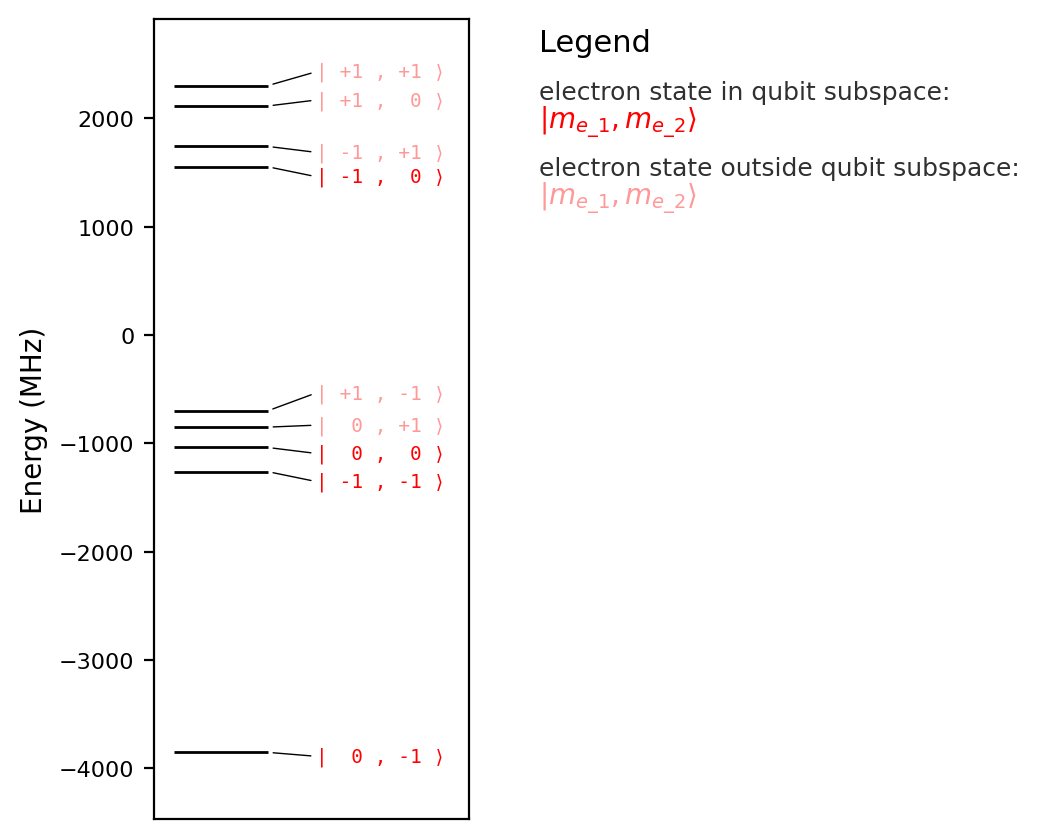

['e_1', 'e_2']

In [20]:
model = simphony.default_multi_nv_model(orientations=[(1,1,1),(1,-1,-1)],
                                        positions=[[0,0,0],[1,3,10]],
                                        nitrogen_isotopes=None,
                                        static_field_strengths=0.01)

model.plot_levels()
model.spin_names

Using `quantization_axis='anisotropy_axis'` makes each spin's **local basis follow its own NV axis**. For multi-orientation models this is often the clearer convention, because the basis now follows the physical principal axis of each center:

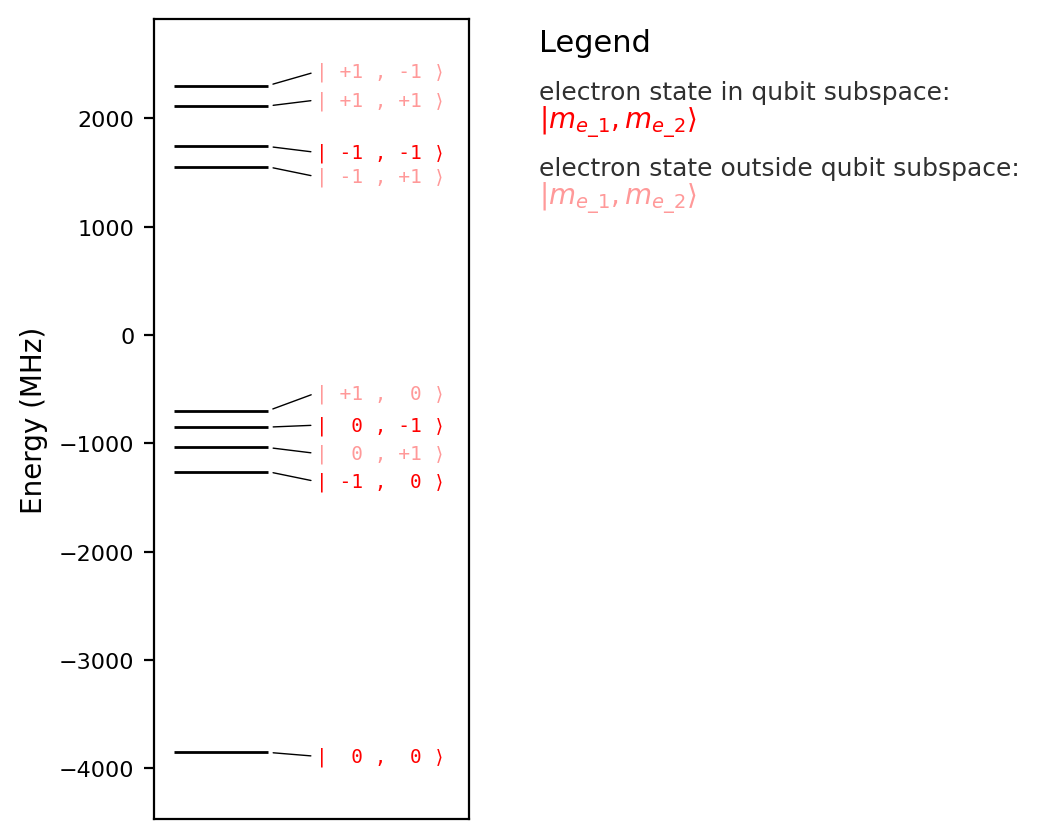

['e_1', 'e_2']

In [21]:
model = simphony.default_multi_nv_model(orientations=[(1,1,1),(1,-1,-1)],
                                        positions=[[0,0,0],[1,10,3]],
                                        nitrogen_isotopes=None,
                                        static_field_strengths=0.01,
                                        quantization_axis='anisotropy_axis')

model.plot_levels()
model.spin_names

Overlaps between the eigenstates and local-$S_z$ product-basis states can be visualized by the model's `test_labeling(output='plot')` method:

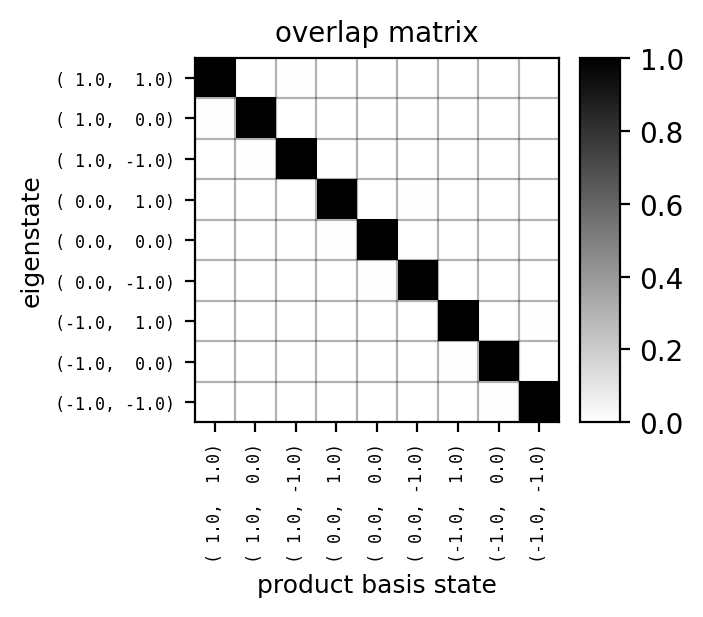

In [22]:
model.test_labeling(output='plot')

Strong diagonal weight means the assigned labels are easy to interpret.

## Summary

The default NV builders provide a compact way to construct physically parameterized NV models:

- `default_nv_model()` creates a single NV-center model.
- `nitrogen_isotope` adds the nitrogen nuclear spin.
- `carbon_atom_indices` selects carbon-13 sites from the hyperfine database.
- `static_field_direction` changes the magnetic-field orientation.
- `quantization_axis` controls the basis used for state labels and labeling diagnostics.
- `default_multi_nv_model()` adds NV-center orientations, positions, local fields, and multi-center interactions.

Use `plot_levels()` to compare spectra after each modeling choice, and use `test_labeling()` when the basis or geometry may make state labels ambiguous.